# Fake News Detection & Optimistic System using NLP & ML

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import re
import string

## 2. Load Dataset

In [2]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

In [3]:
df_true.head(5)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
df_true.head(5)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## 3. Inserting a column "class" as target feature

In [5]:
label_map = {0: "Fake News ", 1: "Real News "}

In [6]:
df_fake.shape, df_true.shape

((23481, 4), (21417, 4))

In [7]:
df_fake["class"] = 0
df_true["class"] = 1

## 4. Merging True and Fake Dataframes

In [8]:
df_merge = pd.concat([df_fake, df_true], axis =0 )
df_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [9]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

## 5. Removing columns which are not required

In [10]:
df = df_merge.drop(["subject","date"], axis=1)

In [11]:
df.isnull().sum()

title    0
text     0
class    0
dtype: int64

## 6. Random Shuffling the dataframe

In [12]:
df = df.sample(frac = 1)

In [13]:
df.head()

,title,text,class
12923,Top German conservative embraces Macron's EU p...,BERLIN (Reuters) - The premier of Germany s mo...,1
12887,China criticises India over crashed drone on b...,BEIJING (Reuters) - China expressed strong di...,1
20687,"BEYONCE DOUBLES DOWN…Debuts #LEMONADE, Another...",Most of the world will be obsessed with Beyonc...,0
14741,THIS IS HUGE! Here’s Proof George Soros Fears ...,The evil George Soros wrote a rare op-ed for T...,0
5046,CIA 'mission' on cars shows concern about next...,SAN FRANCISCO (Reuters) - WikiLeaks documents ...,1


In [14]:
df.reset_index(inplace = True)
df.drop(["index"], axis = 1, inplace = True)

In [15]:
df.columns

Index(['title', 'text', 'class'], dtype='object')

In [16]:
df.head()

,title,text,class
0,Top German conservative embraces Macron's EU p...,BERLIN (Reuters) - The premier of Germany s mo...,1
1,China criticises India over crashed drone on b...,BEIJING (Reuters) - China expressed strong di...,1
2,"BEYONCE DOUBLES DOWN…Debuts #LEMONADE, Another...",Most of the world will be obsessed with Beyonc...,0
3,THIS IS HUGE! Here’s Proof George Soros Fears ...,The evil George Soros wrote a rare op-ed for T...,0
4,CIA 'mission' on cars shows concern about next...,SAN FRANCISCO (Reuters) - WikiLeaks documents ...,1


## 7. Creating a function to process the texts

In [17]:
def wordopt(text):
    text = text.lower()

    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [18]:
# Create combined text
df["content"] = df["title"] + " " + df["text"]

In [19]:
df["content"] = df["content"].apply(wordopt)

## 8. Defining dependent and independent variables

In [20]:
df["content"] = df["title"] + " " + df["text"]
x = df["content"]
y = df["class"]

## 9. Splitting Training and Testing

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, stratify=y, random_state=42
)

## 10. Convert text to vectors

In [22]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    min_df=5,
    ngram_range=(1,2),
    max_features=50000,
    sublinear_tf=True,
    dtype=np.float32
)

xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

## 11. Model 1: Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(xv_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
pred_lr=LR.predict(xv_test)

In [25]:
LR.score(xv_test, y_test)

0.9923385300668152

In [26]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5871
           1       0.99      0.99      0.99      5354

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



## 12. Model 2: Naive Bayes Model

In [27]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(xv_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [28]:
# Make Predictions
pred_nb = NB.predict(xv_test)

In [29]:
# Check Accuracy
print(NB.score(xv_test, y_test))

0.9579510022271714


In [30]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      5871
           1       0.96      0.95      0.96      5354

    accuracy                           0.96     11225
   macro avg       0.96      0.96      0.96     11225
weighted avg       0.96      0.96      0.96     11225



## 13.  Model Comparison (LR vs NB)

In [31]:
# Decision Tree Classification
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
pred_dt = DT.predict(xv_test)

In [33]:
DT.score(xv_test, y_test)

0.9958129175946547

In [34]:
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5871
           1       1.00      0.99      1.00      5354

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225



## 14. Random Forest Classifier

In [35]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
pred_rfc = RFC.predict(xv_test)

In [37]:
print(classification_report(y_test, pred_rfc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5871
           1       1.00      1.00      1.00      5354

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225



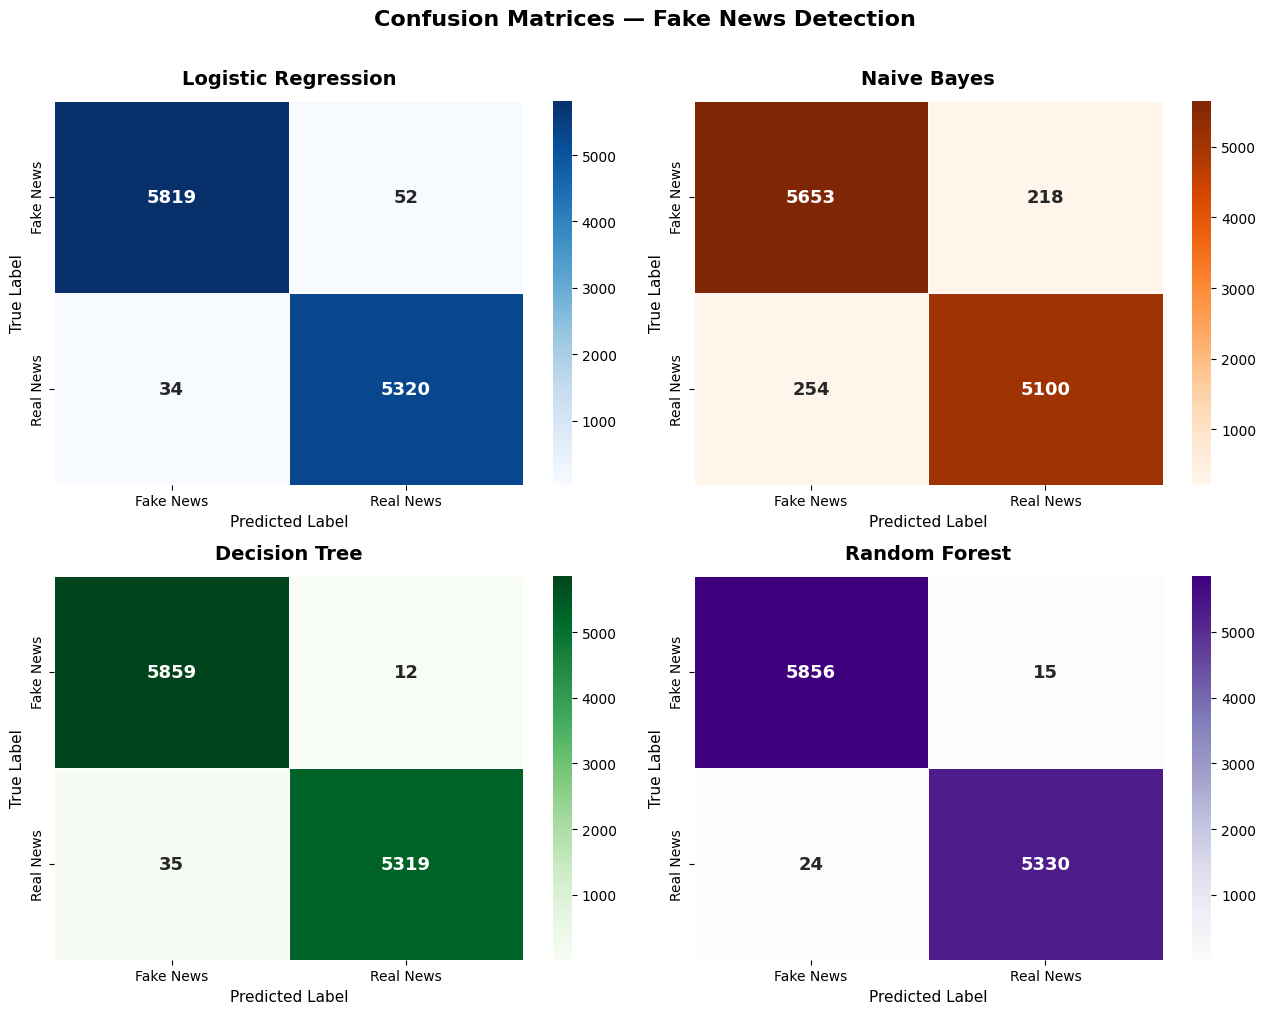

✅ Saved as confusion_matrices.png


In [38]:
# ============================================================
# 15. Confusion Matrix Visualization 
# ============================================================

# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix
# import numpy as np

def plot_confusion_matrix(y_true, y_pred, model_name, ax, color):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Fake News", "Real News"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=color,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"}
    )
    ax.set_title(f"{model_name}", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.tick_params(labelsize=10)

# --- Predictions (already computed above, reused here) ---
# pred_lr  = LR predictions
# pred_nb  = NB predictions
# pred_dt  = DT predictions
# pred_rfc = RFC predictions

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    "Confusion Matrices — Fake News Detection",
    fontsize=16, fontweight="bold", y=1.01
)

plot_confusion_matrix(y_test, pred_lr,  "Logistic Regression", axes[0][0], "Blues")
plot_confusion_matrix(y_test, pred_nb,  "Naive Bayes",         axes[0][1], "Oranges")
plot_confusion_matrix(y_test, pred_dt,  "Decision Tree",       axes[1][0], "Greens")
plot_confusion_matrix(y_test, pred_rfc, "Random Forest",       axes[1][1], "Purples")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved as confusion_matrices.png")

## 15. Final Manual Testing

In [39]:
def output_label(n):
    return "Fake News" if n == 0 else "Real News"


def manual_testing(news):
    if not news.strip():
        print("Please enter valid news text.")
        return

    # Convert input
    new_df = pd.DataFrame({"text": [news]})

    # Preprocess
    new_df["text"] = new_df["text"].apply(wordopt)

    # Vectorize
    new_xv = vectorization.transform(new_df["text"])

    # Predictions
    pred_lr = LR.predict(new_xv)[0]
    pred_nb = NB.predict(new_xv)[0]

    # Probabilities
    prob_lr = LR.predict_proba(new_xv)[0]
    prob_nb = NB.predict_proba(new_xv)[0]

    # Confidence
    conf_lr = prob_lr[pred_lr] * 100
    conf_nb = prob_nb[pred_nb] * 100

    # Output
    print("\n===== RESULT =====")

    print("\n--- Logistic Regression ---")
    print("Prediction:", output_label(pred_lr))
    print(f"Confidence: {conf_lr:.2f}%")

    print("\n--- Naive Bayes ---")
    print("Prediction:", output_label(pred_nb))
    print(f"Confidence: {conf_nb:.2f}%")

    print("\n--- Probability Breakdown ---")
    print(f"LR -> Fake: {prob_lr[0]*100:.2f}% | Real: {prob_lr[1]*100:.2f}%")
    print(f"NB -> Fake: {prob_nb[0]*100:.2f}% | Real: {prob_nb[1]*100:.2f}%")

    # Agreement Check
    if pred_lr == pred_nb:
        print("\n✅ Strong Prediction (Both models agree)")
    else:
        print("\n⚠️ Weak Prediction (Models disagree)")

In [40]:
import pickle

pickle.dump(LR, open("model.pkl", "wb"))
pickle.dump(NB, open("nb_model.pkl", "wb"))
pickle.dump(vectorization, open("vectorizer.pkl", "wb"))